In [ ]:
# Cell 1: Setup & Imports
from google.colab import drive
drive.mount('/content/drive')

!pip install -q flwr-datasets datasets torch torchvision scikit-learn seaborn matplotlib pandas

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import os
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from torchvision import models, datasets, transforms
from torchvision.models import EfficientNet_B0_Weights, EfficientNet_B1_Weights, EfficientNet_B2_Weights
from torch.utils.data import DataLoader, WeightedRandomSampler, Subset
from torchvision.transforms import Compose, ToTensor, Normalize
from sklearn.metrics import roc_auc_score, confusion_matrix
from flwr_datasets.partitioner import DirichletPartitioner
from datasets import Dataset

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.4/93.4 kB 9.9 MB/s eta 0:00:00
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA L4
Using device: cuda:0


In [ ]:
# Cell 2: Configuration
# ============================================================================
# Single alpha=1.5 run. Matches FL simulation exactly (verified from helpers.py / db.sql).
# B0 (Asiri) → P0 (3.9:1), B2 (Lanka) → P1 (2.7:1), B1 (Delmon) → P2 (3.1:1)
# ============================================================================

# --- Dirichlet Partitioning ---
DIRICHLET_ALPHA = 1.5

# --- Training Strategy (matches FL config exactly) ---
MINORITY_BOOST = 0.85              # Power-based rebalancing intensity (FLEX_MED_MINORITY_BOOST=0.85)
LEARNING_RATE = 0.0005             # Base learning rate (matches FL lr=0.0005)
WEIGHT_DECAY = 0.02                # AdamW weight decay (backbone gets 2x)
GRAD_CLIP_NORM = 0.5               # Gradient clipping max norm
LABEL_SMOOTHING = 0.1              # CrossEntropyLoss label smoothing

# --- 2-Phase Progressive Unfreezing (matches helpers.py apply_freeze_strategy) ---
PHASE2_START_ROUND = 5             # R1-4: head only, R5+: 50% backbone
PHASE2_CLASSIFIER_LR_MULT = 0.6   # Phase 2 classifier LR multiplier
PHASE2_BACKBONE_LR_MULT = 0.03    # Phase 2 backbone LR multiplier  → 0.000015
UNFREEZE_FRACTION = 0.50           # Fraction of last block to unfreeze in Phase 2 (capped at 50%)

# --- Fixed Model -> Partition Assignment (verified from FL simulation log6.txt) ---
# Note: ratios are approximate from Dirichlet split; client names in parentheses
MODEL_PARTITION_MAP = {
    "efficientnet_b0": 0,          # Asiri  — 3.9:1 ALL/Healthy ratio
    "efficientnet_b2": 1,          # Lanka  — 2.7:1 ALL/Healthy ratio
    "efficientnet_b1": 2,          # Delmon — 3.1:1 ALL/Healthy ratio
}
NUM_PARTITIONS = 3

# --- Fixed parameters (from FL config / db.sql) ---
SEED = 42                          # Must match FL simulation seed
MIN_PARTITION_SIZE = 400           # Must match FL simulation (dirichlet_min_partition_size=400)
NUM_ROUNDS = 10                    # Max FL rounds (matches db.sql num_rounds=10)
EARLY_STOPPING_PATIENCE = 2        # Stop after this many rounds without val acc improvement
LOCAL_EPOCHS_PER_ROUND = 2         # Local epochs per FL round (matches pyproject.toml local-epochs=2)
TOTAL_EPOCHS = NUM_ROUNDS * LOCAL_EPOCHS_PER_ROUND  # = up to 20 total epochs
BATCH_SIZE = 32
NUM_CLASSES = 2
IMG_SIZE = 224

# --- Dataset Paths (Google Drive) ---
TRAIN_DATASET_PATH = "/content/drive/MyDrive/College/FLEX-Med/backend/datasets/cnmc/cnmc_local_train"
TEST_DATASET_PATH = "/content/drive/MyDrive/College/FLEX-Med/backend/datasets/cnmc/cnmc_public_test"

# --- Model Checkpoint Save Path ---
BENCHMARK_ROOT = "/content/drive/MyDrive/College/FLEX-Med/benchmarks/centralized"
os.makedirs(BENCHMARK_ROOT, exist_ok=True)

print(f"Configuration:")
print(f"  Dirichlet alpha:       {DIRICHLET_ALPHA}")
print(f"  Model -> Partition:    {MODEL_PARTITION_MAP}")
print(f"  Total models:          {len(MODEL_PARTITION_MAP)}")
print(f"  Max epochs:            {TOTAL_EPOCHS} ({NUM_ROUNDS} rounds x {LOCAL_EPOCHS_PER_ROUND}, early stop patience={EARLY_STOPPING_PATIENCE})")
print(f"  Batch size:            {BATCH_SIZE}")
print(f"  Learning rate:         {LEARNING_RATE}")
print(f"  Weight decay:          {WEIGHT_DECAY} (backbone: {WEIGHT_DECAY * 2})")
print(f"  Grad clip norm:        {GRAD_CLIP_NORM}")
print(f"  Label smoothing:       {LABEL_SMOOTHING}")
print(f"  Minority boost:        {MINORITY_BOOST}")
print(f"  Phase 2 start round:   {PHASE2_START_ROUND}  (50% backbone, BN frozen)")
print(f"  Unfreeze fraction:     {UNFREEZE_FRACTION}")
print(f"  Benchmark root:        {BENCHMARK_ROOT}")

Configuration:
  Dirichlet alpha:       1.5
  Model -> Partition:    {'efficientnet_b0': 0, 'efficientnet_b2': 1, 'efficientnet_b1': 2}
  Total models:          3
  Max epochs:            20 (10 rounds x 2, early stop patience=2)
  Batch size:            32
  Learning rate:         0.0005
  Weight decay:          0.02 (backbone: 0.04)
  Grad clip norm:        0.5
  Label smoothing:       0.1
  Minority boost:        0.85
  Phase 2 start round:   5  (50% backbone, BN frozen)
  Unfreeze fraction:     0.5
  Benchmark root:        /content/drive/MyDrive/College/FLEX-Med/benchmarks/centralized


In [ ]:
# Cell 3: Data Loading Functions
# Replicates the exact Dirichlet partitioning from task.py

# --- Transforms (identical to task.py) ---
COMMON_TRANSFORM = Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    ToTensor(),
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

PRIVATE_TRAIN_TRANSFORM = Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)), # Standardize resolution
    transforms.RandomHorizontalFlip(p=0.5), # Handle arbitrary orientation
    transforms.RandomVerticalFlip(p=0.5),   # Cells aren't axis-aligned
    transforms.RandomRotation(15),          # Slight angular variations
    ToTensor(), # Convert to tensor
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), # ImageNet standards
])


class TransformOverrideSubset(torch.utils.data.Dataset):
    """Wraps a nested Subset to apply a different transform (e.g. no augmentation for val)."""

    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
        ds = subset
        self._index_chain = []
        while isinstance(ds, Subset):
            self._index_chain.append(ds.indices)
            ds = ds.dataset
        self._root_dataset = ds

    def _resolve_index(self, idx):
        resolved = idx
        for indices in self._index_chain:
            resolved = indices[resolved]
        return resolved

    def __getitem__(self, idx):
        root_idx = self._resolve_index(idx)
        path, label = self._root_dataset.samples[root_idx]
        img = Image.open(path).convert('RGB')
        return self.transform(img), label

    def __len__(self):
        return len(self.subset)


def create_dirichlet_partitioner(dataset_path, num_partitions, alpha, seed, min_partition_size):
    """Create a Dirichlet partitioner (identical to task.py)."""
    full_dataset = datasets.ImageFolder(root=dataset_path, transform=None)
    image_paths = [path for path, _ in full_dataset.samples]
    labels = [label for _, label in full_dataset.samples]

    hf_dataset = Dataset.from_dict({"image_path": image_paths, "label": labels})
    partitioner = DirichletPartitioner(
        num_partitions=num_partitions, partition_by="label", alpha=alpha,
        min_partition_size=min_partition_size, self_balancing=False, shuffle=True, seed=seed
    )
    partitioner.dataset = hf_dataset
    return partitioner, full_dataset


def load_partition_dataset(partition_id, partitioner, full_dataset, batch_size, minority_boost):
    """Load a Dirichlet partition with train/val split (identical to task.py logic)."""
    partition_dataset = partitioner.load_partition(partition_id)
    partition_paths = partition_dataset["image_path"]

    path_to_idx = {path: idx for idx, (path, _) in enumerate(full_dataset.samples)}
    client_indices = [path_to_idx[path] for path in partition_paths]

    client_dataset = Subset(
        datasets.ImageFolder(root=TRAIN_DATASET_PATH, transform=PRIVATE_TRAIN_TRANSFORM),
        client_indices
    )

    # Stratified 85/15 train/val split
    class_indices = {0: [], 1: []}
    for subset_idx, global_idx in enumerate(client_indices):
        class_indices[full_dataset.targets[global_idx]].append(subset_idx)

    train_indices, val_indices = [], []
    generator = torch.Generator().manual_seed(42)

    for indices in class_indices.values():
        if not indices:
            continue
        perm = torch.randperm(len(indices), generator=generator)
        shuffled = torch.tensor(indices)[perm].tolist()
        split = int(0.85 * len(shuffled))
        train_indices.extend(shuffled[:split])
        val_indices.extend(shuffled[split:])

    train_ds = Subset(client_dataset, train_indices)
    val_ds = TransformOverrideSubset(Subset(client_dataset, val_indices), COMMON_TRANSFORM)

    # Power-based weighted random sampler (identical to task.py)
    train_targets = [full_dataset.targets[client_indices[i]] for i in train_indices]
    class_counts = np.bincount(train_targets, minlength=NUM_CLASSES)

    # Power-based rebalancing: 0.0=natural, 0.5=sqrt, 1.0=full inverse (50/50)
    class_weights = 1.0 / np.maximum(class_counts, 1) ** minority_boost
    sample_weights = [class_weights[label] for label in train_targets]

    sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

    trainloader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler, num_workers=2)
    valloader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2)

    return trainloader, valloader, class_counts


def print_partition_stats(partitioner, full_dataset, alpha, num_partitions):
    """Print partition distribution statistics."""
    client_names = {0: "Asiri (B0)", 1: "Lanka (B2)", 2: "Delmon (B1)"}
    print(f"\n{'='*80}")
    print(f"PARTITION STATISTICS (alpha={alpha}, seed={SEED}, partitions={num_partitions})")
    print(f"{'='*80}")

    total_all, total_healthy = 0, 0
    for pid in range(num_partitions):
        partition = partitioner.load_partition(pid)
        labels = partition["label"]
        n_all = sum(l == 0 for l in labels)
        n_healthy = sum(l == 1 for l in labels)
        total = len(labels)
        all_pct = n_all / total * 100
        healthy_pct = n_healthy / total * 100
        ratio = n_all / n_healthy if n_healthy > 0 else float('inf')
        total_all += n_all
        total_healthy += n_healthy

        name = client_names.get(pid, f"P{pid}")
        print(f"  Partition {pid} ({name}): Total={total:4d} | "
              f"ALL={n_all:4d} ({all_pct:5.1f}%) | Healthy={n_healthy:4d} ({healthy_pct:5.1f}%) | "
              f"Ratio={ratio:.1f}:1")

    overall_total = total_all + total_healthy
    overall_ratio = total_all / total_healthy if total_healthy > 0 else float('inf')
    print(f"  {'-'*74}")
    print(f"  OVERALL: Total={overall_total:4d} | Ratio={overall_ratio:.1f}:1")
    print(f"{'='*80}")


print("Data loading functions defined successfully.")

Data loading functions defined successfully.


In [ ]:
# Cell 4: Model & Training Functions (matches FL pipeline exactly)

# --- Model Creation (identical to helpers.py) ---

def get_initial_dropout_rate(model_type):
    """Get default dropout rate for model architecture."""
    rates = {'efficientnet_b0': 0.40, 'efficientnet_b1': 0.40, 'efficientnet_b2': 0.45}
    return rates.get(model_type.lower(), 0.3)


def add_dropout_to_classifier(model, model_type, dropout_rate=0.3):
    """Add/update dropout layer before the final classifier head (idempotent)."""
    if isinstance(model.classifier[1], nn.Sequential) and isinstance(model.classifier[1][0], nn.Dropout):
        model.classifier[1][0].p = dropout_rate
    else:
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Sequential(nn.Dropout(p=dropout_rate), nn.Linear(in_features, NUM_CLASSES))
    return model


def get_model_by_type(model_type):
    """Create a model with pretrained weights and dropout-enhanced classifier."""
    model_type = model_type.lower()
    dropout_rate = get_initial_dropout_rate(model_type)
    model_map = {
        'efficientnet_b0': (models.efficientnet_b0, EfficientNet_B0_Weights.DEFAULT),
        'efficientnet_b1': (models.efficientnet_b1, EfficientNet_B1_Weights.DEFAULT),
        'efficientnet_b2': (models.efficientnet_b2, EfficientNet_B2_Weights.DEFAULT),
    }
    model_fn, weights = model_map[model_type]
    model = model_fn(weights=weights)
    return add_dropout_to_classifier(model, model_type, dropout_rate)


# --- Frozen BatchNorm (identical to helpers.py) ---

def set_bn_eval(m):
    """Freeze running statistics and parameters for ALL types of BatchNorm layers."""
    if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d)):
        m.eval()
        if m.weight is not None:
            m.weight.requires_grad = False
        if m.bias is not None:
            m.bias.requires_grad = False


# --- Progressive Unfreezing (identical to helpers.py) ---

def freeze_backbone(model, model_type):
    """Freeze all backbone layers, keep only classifier trainable."""
    model_type = model_type.lower()
    for param in model.parameters():
        param.requires_grad = False
    if model_type.startswith('efficientnet'):
        for param in model.classifier.parameters():
            param.requires_grad = True
    return model


def unfreeze_fraction_of_last_block(model, model_type, fraction):
    """Unfreeze a fraction of the final backbone block + bridge layer.
    BN layers are intentionally kept frozen to preserve running statistics.
    Matches helpers.py unfreeze_fraction_of_last_block exactly.
    """
    model_type = model_type.lower()

    if model_type.startswith('efficientnet'):
        # Unfreeze bridge layer (features[-1]) — skip BN layers
        for module in model.features[-1].modules():
            if not isinstance(module, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d)):
                for param in module.parameters(recurse=False):
                    param.requires_grad = True

        # Unfreeze fraction of last MBConv stage (features[-2]) — skip BN layers
        last_block = model.features[-2]
        children = list(last_block.children())
        num_children = len(children)
        num_unfreeze = int(num_children * fraction)
        if fraction > 0.0 and num_unfreeze == 0:
            num_unfreeze = 1

        unfreeze_start_idx = num_children - num_unfreeze
        for i, child in enumerate(children):
            if i >= unfreeze_start_idx:
                for module in child.modules():
                    if isinstance(module, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d)):
                        continue  # Keep BN layers frozen
                    for param in module.parameters(recurse=False):
                        param.requires_grad = True

    return model


def apply_freeze_strategy(model, model_type, simulated_round):
    """2-phase progressive unfreezing (matches helpers.py apply_freeze_strategy).
    Phase 1 (R1-4): Classifier head only — backbone frozen.
    Phase 2 (R5+): 50% of final backbone block unfrozen (BN layers kept frozen).
    """
    # Always start from fully frozen backbone
    model = freeze_backbone(model, model_type)

    if simulated_round < PHASE2_START_ROUND:
        # Phase 1: Head only warm-up
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        phase = f"Phase 1 - Classifier only ({trainable:,} params)"
    else:
        # Phase 2: 50% backbone refinement (BN excluded)
        model = unfreeze_fraction_of_last_block(model, model_type, UNFREEZE_FRACTION)
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        phase = f"Phase 2 - 50% backbone, BN frozen ({trainable:,} params)"

    return model, phase


# --- Discriminative LR Optimizer (identical to task.py train()) ---

def create_optimizer(model, classifier_lr, backbone_lr):
    """Create AdamW optimizer with 4 param groups for discriminative LRs."""
    classifier_decay, classifier_no_decay = [], []
    backbone_decay, backbone_no_decay = [], []

    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        is_classifier = "classifier" in name or "fc" in name
        if is_classifier:
            if len(param.shape) == 1:
                classifier_no_decay.append(param)
            else:
                classifier_decay.append(param)
        else:
            if len(param.shape) == 1:
                backbone_no_decay.append(param)
            else:
                backbone_decay.append(param)

    return torch.optim.AdamW([
        {"params": classifier_decay, "lr": classifier_lr, "weight_decay": WEIGHT_DECAY},
        {"params": classifier_no_decay, "lr": classifier_lr, "weight_decay": 0.0},
        {"params": backbone_decay, "lr": backbone_lr, "weight_decay": WEIGHT_DECAY * 2.0},
        {"params": backbone_no_decay, "lr": backbone_lr, "weight_decay": 0.0}
    ], betas=(0.9, 0.999))


# --- Training & Validation (identical to task.py) ---

def train_one_epoch(model, trainloader, optimizer, criterion, device):
    """Train for a single epoch with frozen BN. Returns (avg_loss, accuracy)."""
    model.train()
    model.apply(set_bn_eval)  # Freeze BatchNorm statistics

    total_loss, total_batches = 0.0, 0
    correct, total = 0, 0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
        optimizer.step()

        total_loss += loss.item()
        total_batches += 1
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    return total_loss / max(total_batches, 1), correct / max(total, 1)


def validate(model, valloader, criterion, device):
    """Validate model. Returns (avg_loss, accuracy)."""
    model.eval()
    total_loss, total_batches = 0.0, 0
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in valloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            total_loss += criterion(outputs, labels).item()
            total_batches += 1
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return total_loss / max(total_batches, 1), correct / max(total, 1)


# --- Evaluation (identical metrics to task.py test()) ---

def evaluate(model, testloader, device):
    """Comprehensive evaluation with all metrics matching task.py test()."""
    model.to(device)
    model.eval()
    criterion = nn.CrossEntropyLoss()
    correct, total, total_loss = 0, 0, 0.0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            total_loss += criterion(outputs, labels).item()
            probs = F.softmax(outputs, dim=1)
            all_probs.extend(probs.cpu().tolist())
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    accuracy = correct / total if total > 0 else 0.0
    loss = total_loss / len(testloader) if len(testloader) > 0 else 0.0
    all_preds = torch.tensor(all_preds)
    all_labels = torch.tensor(all_labels)
    all_probs = torch.tensor(all_probs)

    # Confusion matrix (class 0 = Leukemia/ALL, class 1 = Healthy)
    TP = ((all_preds == 0) & (all_labels == 0)).sum().item()
    FP = ((all_preds == 0) & (all_labels == 1)).sum().item()
    FN = ((all_preds == 1) & (all_labels == 0)).sum().item()
    TN = ((all_preds == 1) & (all_labels == 1)).sum().item()

    leukemia_acc = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    healthy_acc = TN / (TN + FP) if (TN + FP) > 0 else 0.0
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = leukemia_acc
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    specificity = healthy_acc
    class_gap = abs(healthy_acc - leukemia_acc)

    try:
        # pos_label=0: ALL (Leukemia) is the positive class; all_probs[:,0] = P(ALL)
        roc_auc = roc_auc_score(all_labels.numpy(), all_probs[:, 0].numpy(), pos_label=0)
    except Exception:
        roc_auc = (recall + specificity) / 2

    return {
        "loss": round(loss, 6),
        "accuracy": round(accuracy, 6),
        "precision": round(precision, 6),
        "recall": round(recall, 6),
        "f1_score": round(f1_score, 6),
        "specificity": round(specificity, 6),
        "roc_auc": round(roc_auc, 6),
        "leukemia_accuracy": round(leukemia_acc, 6),
        "healthy_accuracy": round(healthy_acc, 6),
        "class_gap": round(class_gap, 6),
        "confusion_matrix": {"TP": TP, "FP": FP, "FN": FN, "TN": TN},
        "num_samples": total,
        "all_preds": all_preds.numpy(),
        "all_labels": all_labels.numpy(),
    }


print("Functions defined successfully.")

Functions defined successfully.


In [ ]:
# Cell 5: Training Loop (3 EfficientNet models, single alpha=1.5)
# Simulates FL rounds: each round = 2-phase freeze strategy + discriminative LRs + 2 local epochs
# Early stopping: halts when val accuracy doesn't improve for EARLY_STOPPING_PATIENCE rounds,
# then restores best model weights.

import random
import copy

# Deterministic seeding (matches FL client_app.py)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"{'#'*80}")
print(f"# CENTRALIZED TRAINING (Dirichlet alpha={DIRICHLET_ALPHA})")
print(f"# Up to {NUM_ROUNDS} simulated rounds x {LOCAL_EPOCHS_PER_ROUND} local epochs (early stop patience={EARLY_STOPPING_PATIENCE})")
print(f"{'#'*80}")

# Create Dirichlet partitioner
partitioner, full_dataset = create_dirichlet_partitioner(
    TRAIN_DATASET_PATH, NUM_PARTITIONS, DIRICHLET_ALPHA, SEED, MIN_PARTITION_SIZE
)
print_partition_stats(partitioner, full_dataset, DIRICHLET_ALPHA, NUM_PARTITIONS)

# Loss function (identical to task.py — CrossEntropyLoss with label smoothing)
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

trained_models = {}       # {model_type: model}
training_history = {}     # {model_type: history_dict}

for model_type, partition_id in MODEL_PARTITION_MAP.items():
    print(f"\n{'='*70}")
    print(f"TRAINING: {model_type.upper()} on Partition {partition_id}")
    print(f"{'='*70}")

    # Load data partition
    trainloader, valloader, class_counts = load_partition_dataset(
        partition_id, partitioner, full_dataset, BATCH_SIZE, MINORITY_BOOST
    )
    n_leukemia, n_healthy = class_counts[0], class_counts[1]
    ratio = n_leukemia / n_healthy if n_healthy > 0 else float('inf')
    print(f"Training samples: {n_leukemia + n_healthy} (ALL: {n_leukemia}, Healthy: {n_healthy}, Ratio: {ratio:.1f}:1)")
    print(f"Validation samples: {len(valloader.dataset)}")

    # Create model
    model = get_model_by_type(model_type)
    model.to(DEVICE)

    history = {
        "train_loss": [], "train_acc": [],
        "val_loss": [], "val_acc": [],
        "classifier_lr": [], "backbone_lr": [], "phase": [],
        "round": []
    }

    # Early stopping state
    best_val_acc = 0.0
    best_model_state = None
    best_round_num = 1
    rounds_since_best = 0

    start_time = time.time()

    for sim_round in range(1, NUM_ROUNDS + 1):
        # Apply 2-phase freeze strategy (identical to helpers.py apply_freeze_strategy)
        model, phase_desc = apply_freeze_strategy(model, model_type, sim_round)

        # Compute discriminative LRs (identical to client_app.py)
        if sim_round < PHASE2_START_ROUND:
            # Phase 1: Head only warm-up (R1-4)
            classifier_lr = LEARNING_RATE
            backbone_lr = 0.0
        else:
            # Phase 2: 50% backbone refinement (R5+)
            classifier_lr = LEARNING_RATE * PHASE2_CLASSIFIER_LR_MULT
            backbone_lr = LEARNING_RATE * PHASE2_BACKBONE_LR_MULT

        # Create optimizer (recreated each round as freeze state changes)
        optimizer = create_optimizer(model, classifier_lr, backbone_lr)

        # Train for LOCAL_EPOCHS_PER_ROUND epochs
        for local_epoch in range(LOCAL_EPOCHS_PER_ROUND):
            train_loss, train_acc = train_one_epoch(model, trainloader, optimizer, criterion, DEVICE)
            val_loss, val_acc = validate(model, valloader, criterion, DEVICE)

            history["train_loss"].append(train_loss)
            history["train_acc"].append(train_acc)
            history["val_loss"].append(val_loss)
            history["val_acc"].append(val_acc)
            history["classifier_lr"].append(classifier_lr)
            history["backbone_lr"].append(backbone_lr)
            history["phase"].append(phase_desc)
            history["round"].append(sim_round)

        # Log every round (use last local epoch values)
        improved = val_acc > best_val_acc
        marker = " ★" if improved else f"  (no improvement ×{rounds_since_best + 1})"
        print(f"  Round {sim_round:2d}/{NUM_ROUNDS} | {phase_desc}")
        print(f"    CLR: {classifier_lr:.6f} | BLR: {backbone_lr:.6f} | "
              f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.2%} | "
              f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.2%}{marker}")

        # Early stopping check
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = copy.deepcopy(model.state_dict())
            best_round_num = sim_round
            rounds_since_best = 0
        else:
            rounds_since_best += 1
            if rounds_since_best >= EARLY_STOPPING_PATIENCE:
                print(f"  Early stopping at round {sim_round} "
                      f"(best val acc {best_val_acc:.2%} at round {best_round_num})")
                break

    # Restore best model weights
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    history["best_round"] = best_round_num

    elapsed = time.time() - start_time
    actual_rounds = sim_round  # Last round executed
    print(f"\nCompleted {actual_rounds} rounds in {elapsed:.1f}s | "
          f"Best Val Acc: {best_val_acc:.2%} at Round {best_round_num}")

    # Save best model checkpoint
    checkpoint_path = os.path.join(BENCHMARK_ROOT, f"{model_type}_partition{partition_id}.pt")
    torch.save({
        'model_type': model_type,
        'num_classes': NUM_CLASSES,
        'state_dict': model.state_dict(),
        'partition_id': partition_id,
        'alpha': DIRICHLET_ALPHA,
        'best_val_acc': best_val_acc,
        'best_round': best_round_num,
    }, checkpoint_path)
    print(f"Saved: {checkpoint_path}")

    trained_models[model_type] = model
    training_history[model_type] = history

print(f"\n{'#'*80}")
print(f"ALL TRAINING COMPLETE ({len(trained_models)} models)")
print(f"{'#'*80}")

################################################################################
# CENTRALIZED TRAINING (Dirichlet alpha=1.5)
# Up to 10 simulated rounds x 2 local epochs (early stop patience=2)
################################################################################

PARTITION STATISTICS (alpha=1.5, seed=42, partitions=3)
  Partition 0 (Asiri (B0)): Total=2531 | ALL=2013 ( 79.5%) | Healthy= 518 ( 20.5%) | Ratio=3.9:1
  Partition 1 (Lanka (B2)): Total=3954 | ALL=2873 ( 72.7%) | Healthy=1081 ( 27.3%) | Ratio=2.7:1
  Partition 2 (Delmon (B1)): Total=2288 | ALL=1728 ( 75.5%) | Healthy= 560 ( 24.5%) | Ratio=3.1:1
  --------------------------------------------------------------------------
  OVERALL: Total=8773 | Ratio=3.1:1

TRAINING: EFFICIENTNET_B0 on Partition 0
Training samples: 2151 (ALL: 1711, Healthy: 440, Ratio: 3.9:1)
Validation samples: 380
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/effic

100%|██████████| 20.5M/20.5M [00:00<00:00, 198MB/s]


  Round  1/10 | Phase 1 - Classifier only (2,562 params)
    CLR: 0.000500 | BLR: 0.000000 | Train Loss: 0.6434, Acc: 64.71% | Val Loss: 0.5419, Acc: 82.89% ★
  Round  2/10 | Phase 1 - Classifier only (2,562 params)
    CLR: 0.000500 | BLR: 0.000000 | Train Loss: 0.6259, Acc: 67.27% | Val Loss: 0.5030, Acc: 82.63%  (no improvement ×1)
  Round  3/10 | Phase 1 - Classifier only (2,562 params)
    CLR: 0.000500 | BLR: 0.000000 | Train Loss: 0.6005, Acc: 69.78% | Val Loss: 0.5005, Acc: 83.16% ★
  Round  4/10 | Phase 1 - Classifier only (2,562 params)
    CLR: 0.000500 | BLR: 0.000000 | Train Loss: 0.5966, Acc: 70.80% | Val Loss: 0.4963, Acc: 82.37%  (no improvement ×1)
  Round  5/10 | Phase 2 - 50% backbone, BN frozen (1,124,146 params)
    CLR: 0.000300 | BLR: 0.000015 | Train Loss: 0.5896, Acc: 70.94% | Val Loss: 0.4499, Acc: 85.26% ★
  Round  6/10 | Phase 2 - 50% backbone, BN frozen (1,124,146 params)
    CLR: 0.000300 | BLR: 0.000015 | Train Loss: 0.5646, Acc: 74.57% | Val Loss: 0.4333

100%|██████████| 35.2M/35.2M [00:00<00:00, 222MB/s]


  Round  1/10 | Phase 1 - Classifier only (2,818 params)
    CLR: 0.000500 | BLR: 0.000000 | Train Loss: 0.5420, Acc: 76.46% | Val Loss: 0.4956, Acc: 80.98% ★
  Round  2/10 | Phase 1 - Classifier only (2,818 params)
    CLR: 0.000500 | BLR: 0.000000 | Train Loss: 0.5328, Acc: 77.74% | Val Loss: 0.5004, Acc: 80.64%  (no improvement ×1)
  Round  3/10 | Phase 1 - Classifier only (2,818 params)
    CLR: 0.000500 | BLR: 0.000000 | Train Loss: 0.5348, Acc: 76.96% | Val Loss: 0.4823, Acc: 82.32% ★
  Round  4/10 | Phase 1 - Classifier only (2,818 params)
    CLR: 0.000500 | BLR: 0.000000 | Train Loss: 0.5082, Acc: 79.38% | Val Loss: 0.4912, Acc: 81.31%  (no improvement ×1)
  Round  5/10 | Phase 2 - 50% backbone, BN frozen (2,378,202 params)
    CLR: 0.000300 | BLR: 0.000015 | Train Loss: 0.5038, Acc: 80.18% | Val Loss: 0.4864, Acc: 81.65%  (no improvement ×2)
  Early stopping at round 5 (best val acc 82.32% at round 3)

Completed 5 rounds in 1347.5s | Best Val Acc: 82.32% at Round 3
Saved: /co

100%|██████████| 30.1M/30.1M [00:00<00:00, 237MB/s]


  Round  1/10 | Phase 1 - Classifier only (2,562 params)
    CLR: 0.000500 | BLR: 0.000000 | Train Loss: 0.5864, Acc: 73.56% | Val Loss: 0.5859, Acc: 75.00% ★
  Round  2/10 | Phase 1 - Classifier only (2,562 params)
    CLR: 0.000500 | BLR: 0.000000 | Train Loss: 0.5661, Acc: 74.07% | Val Loss: 0.5718, Acc: 75.87% ★
  Round  3/10 | Phase 1 - Classifier only (2,562 params)
    CLR: 0.000500 | BLR: 0.000000 | Train Loss: 0.5538, Acc: 74.79% | Val Loss: 0.5795, Acc: 72.97%  (no improvement ×1)
  Round  4/10 | Phase 1 - Classifier only (2,562 params)
    CLR: 0.000500 | BLR: 0.000000 | Train Loss: 0.5477, Acc: 76.54% | Val Loss: 0.5368, Acc: 77.33% ★
  Round  5/10 | Phase 2 - 50% backbone, BN frozen (1,967,442 params)
    CLR: 0.000300 | BLR: 0.000015 | Train Loss: 0.5571, Acc: 75.82% | Val Loss: 0.4921, Acc: 80.52% ★
  Round  6/10 | Phase 2 - 50% backbone, BN frozen (1,967,442 params)
    CLR: 0.000300 | BLR: 0.000015 | Train Loss: 0.5343, Acc: 77.01% | Val Loss: 0.5423, Acc: 76.45%  (no 

In [ ]:
# Cell 6: Evaluation on Unseen Test Set

print(f"Loading test dataset from: {TEST_DATASET_PATH}")
test_dataset = datasets.ImageFolder(root=TEST_DATASET_PATH, transform=COMMON_TRANSFORM)
testloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print(f"Test samples: {len(test_dataset)} (Classes: {test_dataset.class_to_idx})")

eval_results = {}  # {model_type: metrics_dict}

print(f"\n{'='*80}")
print(f"EVALUATING CENTRALIZED MODELS (alpha={DIRICHLET_ALPHA})")
print(f"{'='*80}")

CLIENT_NAMES = {"efficientnet_b0": "Asiri", "efficientnet_b2": "Lanka", "efficientnet_b1": "Delmon"}

for model_type, model in trained_models.items():
    partition_id = MODEL_PARTITION_MAP[model_type]
    client_name = CLIENT_NAMES.get(model_type, model_type)
    print(f"\n  {model_type.upper()} ({client_name}, Partition {partition_id}):")
    metrics = evaluate(model, testloader, DEVICE)
    eval_results[model_type] = metrics

    cm = metrics["confusion_matrix"]
    print(f"    Accuracy:     {metrics['accuracy']:.4f}")
    print(f"    Precision:    {metrics['precision']:.4f}")
    print(f"    Recall:       {metrics['recall']:.4f}")
    print(f"    F1 Score:     {metrics['f1_score']:.4f}")
    print(f"    Specificity:  {metrics['specificity']:.4f}")
    print(f"    ROC-AUC:      {metrics['roc_auc']:.4f}")
    print(f"    Leukemia Acc: {metrics['leukemia_accuracy']:.4f}")
    print(f"    Healthy Acc:  {metrics['healthy_accuracy']:.4f}")
    print(f"    Class Gap:    {metrics['class_gap']:.4f}")
    print(f"    CM: TP={cm['TP']}, FP={cm['FP']}, FN={cm['FN']}, TN={cm['TN']}")

print(f"\n{'='*80}")
print("EVALUATION COMPLETE")
print(f"{'='*80}")

Loading test dataset from: /content/drive/MyDrive/College/FLEX-Med/backend/datasets/cnmc/cnmc_public_test
Test samples: 1252 (Classes: {'all': 0, 'hem': 1})

EVALUATING CENTRALIZED MODELS (alpha=1.5)

  EFFICIENTNET_B0 (Asiri, Partition 0):
    Accuracy:     0.6318
    Precision:    0.5864
    Recall:       0.8946
    F1 Score:     0.7084
    Specificity:  0.3690
    ROC-AUC:      0.6318
    Leukemia Acc: 0.8946
    Healthy Acc:  0.3690
    Class Gap:    0.5256
    CM: TP=560, FP=395, FN=66, TN=231

  EFFICIENTNET_B2 (Lanka, Partition 1):
    Accuracy:     0.7212
    Precision:    0.6704
    Recall:       0.8706
    F1 Score:     0.7575
    Specificity:  0.5719
    ROC-AUC:      0.7212
    Leukemia Acc: 0.8706
    Healthy Acc:  0.5719
    Class Gap:    0.2987
    CM: TP=545, FP=268, FN=81, TN=358

  EFFICIENTNET_B1 (Delmon, Partition 2):
    Accuracy:     0.7300
    Precision:    0.6880
    Recall:       0.8419
    F1 Score:     0.7572
    Specificity:  0.6182
    ROC-AUC:      0.7300


In [ ]:
# Cell 7: Results Table

CLIENT_NAMES = {"efficientnet_b0": "Asiri", "efficientnet_b2": "Lanka", "efficientnet_b1": "Delmon"}

metric_names = [
    "accuracy", "precision", "recall", "f1_score",
    "specificity", "roc_auc", "leukemia_accuracy", "healthy_accuracy",
    "class_gap", "loss"
]

table_data = {}
for model_type in MODEL_PARTITION_MAP:
    if model_type in eval_results:
        partition_id = MODEL_PARTITION_MAP[model_type]
        client_name = CLIENT_NAMES.get(model_type, model_type)
        col_name = f"{model_type}\n({client_name}, P{partition_id})"
        table_data[col_name] = [
            f"{eval_results[model_type][m]:.4f}" for m in metric_names
        ]

df = pd.DataFrame(table_data, index=[m.replace('_', ' ').title() for m in metric_names])

print(f"\n{'='*80}")
print(f"CENTRALIZED BENCHMARK RESULTS (Dirichlet alpha={DIRICHLET_ALPHA})")
print(f"{'='*80}")
print(df.to_string())
print()

# Summary row
print(f"\n{'='*80}")
print("SUMMARY")
print(f"{'='*80}")

summary_rows = []
for model_type in MODEL_PARTITION_MAP:
    if model_type in eval_results:
        r = eval_results[model_type]
        summary_rows.append({
            "Model": model_type,
            "Client": CLIENT_NAMES.get(model_type, "-"),
            "Partition": MODEL_PARTITION_MAP[model_type],
            "Accuracy": f"{r['accuracy']:.4f}",
            "Recall": f"{r['recall']:.4f}",
            "F1": f"{r['f1_score']:.4f}",
            "ROC-AUC": f"{r['roc_auc']:.4f}",
            "Class Gap": f"{r['class_gap']:.4f}",
        })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))
summary_df


CENTRALIZED BENCHMARK RESULTS (Dirichlet alpha=1.5)
                  efficientnet_b0\n(Asiri, P0) efficientnet_b2\n(Lanka, P1) efficientnet_b1\n(Delmon, P2)
Accuracy                                0.6318                       0.7212                        0.7300
Precision                               0.5864                       0.6704                        0.6880
Recall                                  0.8946                       0.8706                        0.8419
F1 Score                                0.7084                       0.7575                        0.7572
Specificity                             0.3690                       0.5719                        0.6182
Roc Auc                                 0.6318                       0.7212                        0.7300
Leukemia Accuracy                       0.8946                       0.8706                        0.8419
Healthy Accuracy                        0.3690                       0.5719                        

,Model,Client,Partition,Accuracy,Recall,F1,ROC-AUC,Class Gap
0,efficientnet_b0,Asiri,0,0.6318,0.8946,0.7084,0.6318,0.5256
1,efficientnet_b2,Lanka,1,0.7212,0.8706,0.7575,0.7212,0.2987
2,efficientnet_b1,Delmon,2,0.7300,0.8419,0.7572,0.7300,0.2236


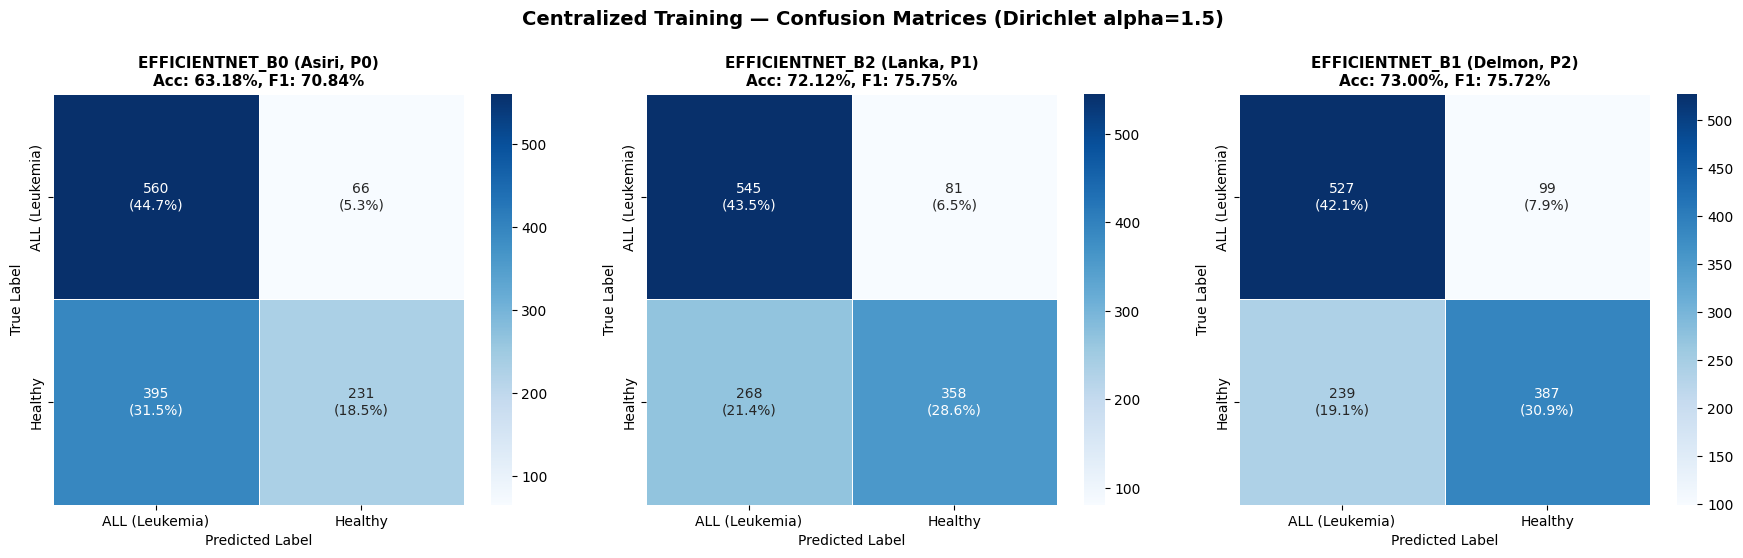

Saved to /content/drive/MyDrive/College/FLEX-Med/benchmarks/centralized/confusion_matrices.png


In [ ]:
# Cell 8: Confusion Matrices

CLIENT_NAMES = {"efficientnet_b0": "Asiri", "efficientnet_b2": "Lanka", "efficientnet_b1": "Delmon"}
class_labels = ["ALL (Leukemia)", "Healthy"]
model_list = list(MODEL_PARTITION_MAP.keys())

fig, axes = plt.subplots(1, len(model_list), figsize=(6 * len(model_list), 5))

for idx, model_type in enumerate(model_list):
    results = eval_results[model_type]
    cm = confusion_matrix(results["all_labels"], results["all_preds"])
    cm_pct = cm.astype('float') / cm.sum() * 100

    annot = np.empty_like(cm, dtype=object)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f"{cm[i, j]}\n({cm_pct[i, j]:.1f}%)"

    partition_id = MODEL_PARTITION_MAP[model_type]
    client_name = CLIENT_NAMES.get(model_type, model_type)
    sns.heatmap(
        cm, annot=annot, fmt='', cmap='Blues', ax=axes[idx],
        xticklabels=class_labels, yticklabels=class_labels,
        cbar=True, square=True, linewidths=0.5
    )
    axes[idx].set_title(
        f"{model_type.upper()} ({client_name}, P{partition_id})\n"
        f"Acc: {results['accuracy']:.2%}, F1: {results['f1_score']:.2%}",
        fontsize=11, fontweight='bold'
    )
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

fig.suptitle(
    f'Centralized Training — Confusion Matrices (Dirichlet alpha={DIRICHLET_ALPHA})',
    fontsize=14, fontweight='bold', y=1.05
)
plt.tight_layout()
save_path = os.path.join(BENCHMARK_ROOT, "confusion_matrices.png")
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {save_path}")

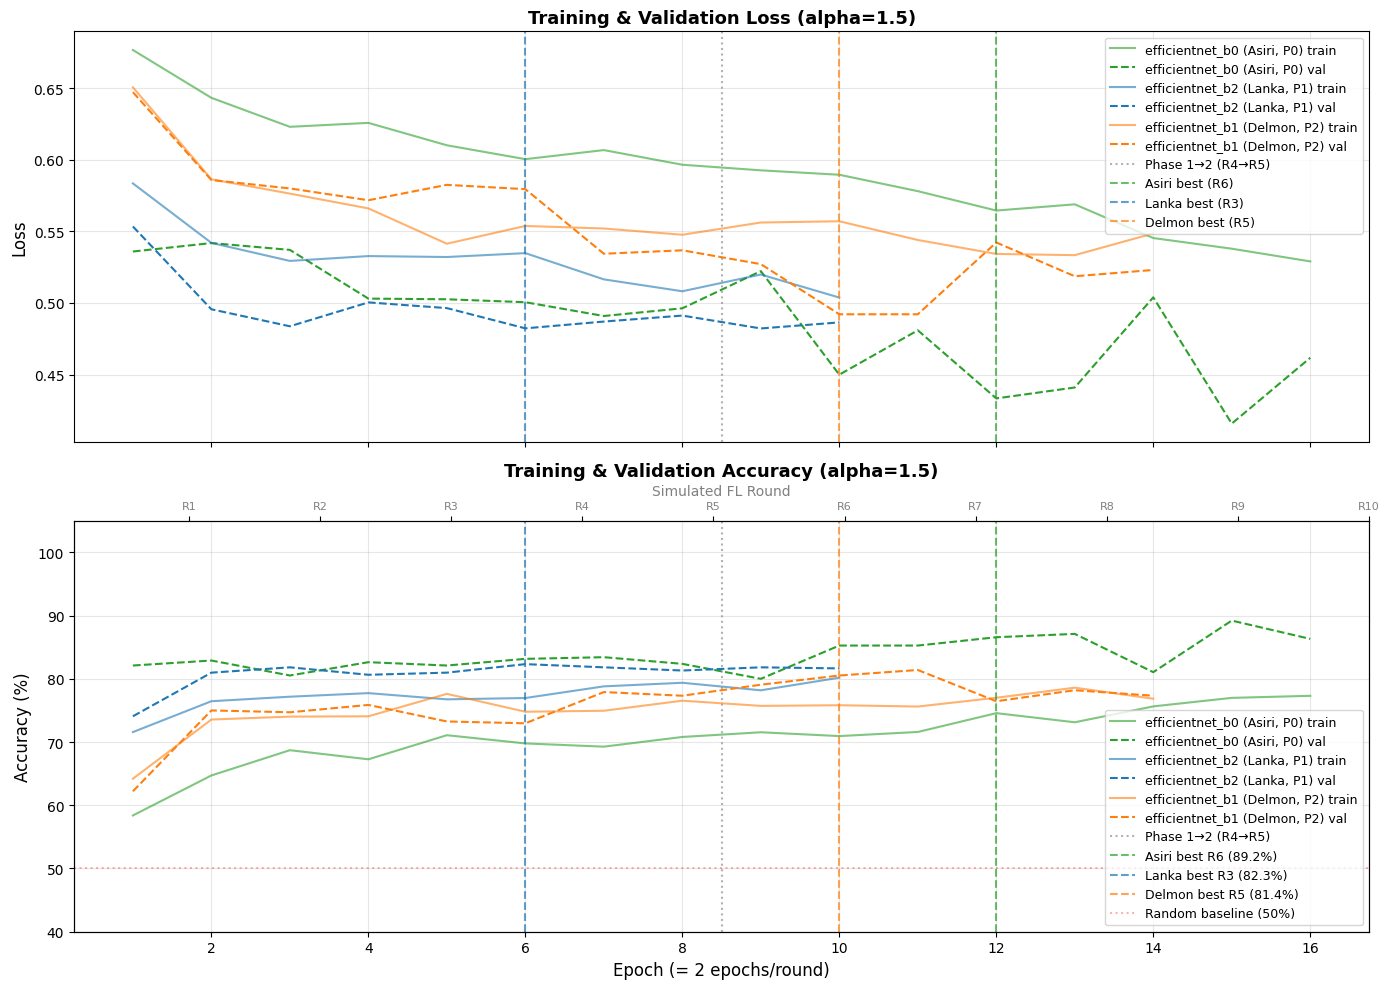

Saved to /content/drive/MyDrive/College/FLEX-Med/benchmarks/centralized/training_curves.png


In [ ]:
# Cell 9: Training Curves

# B0=Asiri, B2=Lanka, B1=Delmon — colors match client assignment
colors = {'efficientnet_b0': '#2ca02c', 'efficientnet_b2': '#1f77b4', 'efficientnet_b1': '#ff7f0e'}
CLIENT_NAMES = {"efficientnet_b0": "Asiri", "efficientnet_b2": "Lanka", "efficientnet_b1": "Delmon"}

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Phase 1→2 boundary: Phase 2 starts at PHASE2_START_ROUND (R5), so boundary is after R4
# With LOCAL_EPOCHS_PER_ROUND epochs per round: epoch index = round * LOCAL_EPOCHS_PER_ROUND
phase1_end_epoch = (PHASE2_START_ROUND - 1) * LOCAL_EPOCHS_PER_ROUND + 0.5  # After R4 = 8.5

# --- Loss Plot ---
for model_type in MODEL_PARTITION_MAP:
    if model_type not in training_history:
        continue
    h = training_history[model_type]
    n_epochs = len(h["train_loss"])
    epochs_range = range(1, n_epochs + 1)
    color = colors.get(model_type, 'gray')
    partition_id = MODEL_PARTITION_MAP[model_type]
    client_name = CLIENT_NAMES.get(model_type, model_type)
    label = f"{model_type} ({client_name}, P{partition_id})"
    axes[0].plot(epochs_range, h["train_loss"], '-', color=color, alpha=0.6, label=f"{label} train")
    axes[0].plot(epochs_range, h["val_loss"], '--', color=color, alpha=1.0, label=f"{label} val")

axes[0].axvline(x=phase1_end_epoch, color='gray', linestyle=':', alpha=0.6, label='Phase 1→2 (R4→R5)')

# Best round markers per model (loss plot)
for model_type in MODEL_PARTITION_MAP:
    if model_type not in training_history:
        continue
    best_round = training_history[model_type].get("best_round")
    if best_round:
        color = colors.get(model_type, 'gray')
        client_name = CLIENT_NAMES.get(model_type, model_type)
        best_epoch = best_round * LOCAL_EPOCHS_PER_ROUND
        axes[0].axvline(x=best_epoch, color=color, linestyle='--', alpha=0.7, linewidth=1.5,
                        label=f"{client_name} best (R{best_round})")

axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title(f'Training & Validation Loss (alpha={DIRICHLET_ALPHA})', fontsize=13, fontweight='bold')
axes[0].legend(loc='upper right', fontsize=9)
axes[0].grid(True, alpha=0.3)

# --- Accuracy Plot ---
for model_type in MODEL_PARTITION_MAP:
    if model_type not in training_history:
        continue
    h = training_history[model_type]
    n_epochs = len(h["train_acc"])
    epochs_range = range(1, n_epochs + 1)
    color = colors.get(model_type, 'gray')
    partition_id = MODEL_PARTITION_MAP[model_type]
    client_name = CLIENT_NAMES.get(model_type, model_type)
    label = f"{model_type} ({client_name}, P{partition_id})"
    axes[1].plot(epochs_range, [a * 100 for a in h["train_acc"]], '-', color=color, alpha=0.6, label=f"{label} train")
    axes[1].plot(epochs_range, [a * 100 for a in h["val_acc"]], '--', color=color, alpha=1.0, label=f"{label} val")

axes[1].axvline(x=phase1_end_epoch, color='gray', linestyle=':', alpha=0.6, label='Phase 1→2 (R4→R5)')

# Best round markers per model (accuracy plot)
for model_type in MODEL_PARTITION_MAP:
    if model_type not in training_history:
        continue
    best_round = training_history[model_type].get("best_round")
    if best_round:
        color = colors.get(model_type, 'gray')
        client_name = CLIENT_NAMES.get(model_type, model_type)
        best_epoch = best_round * LOCAL_EPOCHS_PER_ROUND
        best_acc = max(training_history[model_type]["val_acc"]) * 100
        axes[1].axvline(x=best_epoch, color=color, linestyle='--', alpha=0.7, linewidth=1.5,
                        label=f"{client_name} best R{best_round} ({best_acc:.1f}%)")

axes[1].axhline(y=50, color='red', linestyle=':', alpha=0.3, label='Random baseline (50%)')
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_xlabel(f'Epoch (= {LOCAL_EPOCHS_PER_ROUND} epochs/round)', fontsize=12)
axes[1].set_title(f'Training & Validation Accuracy (alpha={DIRICHLET_ALPHA})', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right', fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([40, 105])

# Add round markers on secondary x-axis
max_epochs = max(len(h["val_acc"]) for h in training_history.values()) if training_history else TOTAL_EPOCHS
round_ticks = [r * LOCAL_EPOCHS_PER_ROUND for r in range(1, NUM_ROUNDS + 1)]
ax2 = axes[1].twiny()
ax2.set_xlim(axes[1].get_xlim())
ax2.set_xticks(round_ticks)
ax2.set_xticklabels([f"R{r}" for r in range(1, NUM_ROUNDS + 1)], fontsize=8, color='gray')
ax2.set_xlabel('Simulated FL Round', fontsize=10, color='gray')

plt.tight_layout()
save_path = os.path.join(BENCHMARK_ROOT, "training_curves.png")
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {save_path}")